# Task-1: Construction of Triangular Filters

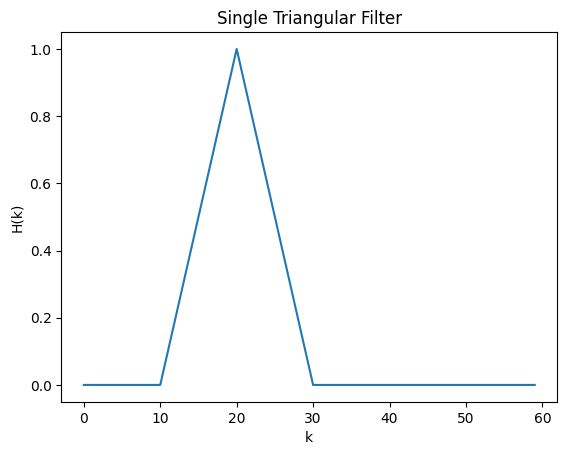

In [ ]:
# Task-1 (i)
import numpy as np
import matplotlib.pyplot as plt

def triangular_filter(k, a, b, c):
    H = np.zeros_like(k, dtype=float)

    for i in range(len(k)):
        if k[i] >= a and k[i] <= b:
            H[i] = (k[i] - a) / (b - a)
        elif k[i] >= b and k[i] <= c:
            H[i] = (c - k[i]) / (c - b)

    return H

# Example
k = np.arange(0, 60)
H = triangular_filter(k, 10, 20, 30)

plt.plot(k, H)
plt.title("Single Triangular Filter")
plt.xlabel("k")
plt.ylabel("H(k)")
plt.show()

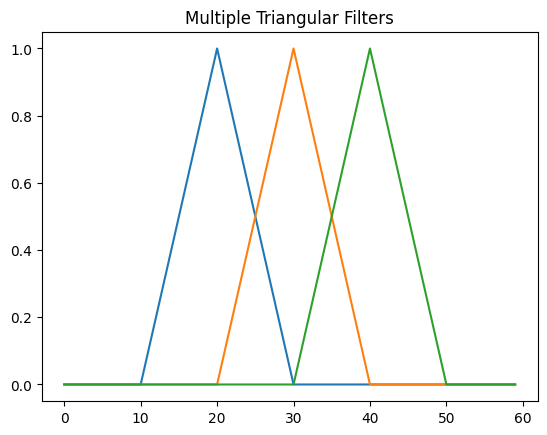

In [ ]:
# Multiple Triangle Filters
filters = [(10,20,30), (20,30,40), (30,40,50)]

for (a,b,c) in filters:
    H = triangular_filter(k, a, b, c)
    plt.plot(k, H)

plt.title("Multiple Triangular Filters")
plt.show()

Plot of WIDE TRIANGLE: 


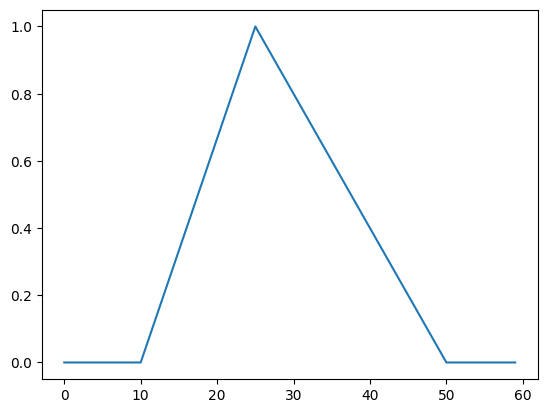


Plot of NARROW TRIANGLE: 


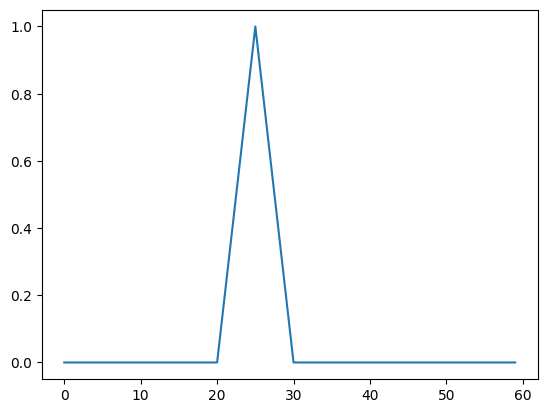

In [ ]:
# wide
print(f"Plot of WIDE TRIANGLE: ")
H1=triangular_filter(k, 10, 25, 50)
plt.plot(k, H1)
plt.show()
print(f"\nPlot of NARROW TRIANGLE: ")
H2=triangular_filter(k, 20, 25, 30)
plt.plot(k, H2)
plt.show()

# TASK-2: Design of Mel filter bank

In [19]:
import numpy as np
import matplotlib.pyplot as plt


# -----------------------------
# Hz ↔ Mel
# -----------------------------
def hz_to_mel(f):
    return 2595 * np.log10(1 + f / 700)

def mel_to_hz(m):
    return 700 * (10**(m / 2595) - 1)


# -----------------------------
# Build Mel Filter Bank (CORE)
# -----------------------------
def mel_filter_bank(fs, N, M):

    fmin = 0
    fmax = fs / 2

    # Mel conversion
    mel_min = hz_to_mel(fmin)
    mel_max = hz_to_mel(fmax)

    mel_points = np.linspace(mel_min, mel_max, M + 2)
    freq_points = mel_to_hz(mel_points)

    # FFT bins
    bins = np.floor((N + 1) * freq_points / fs).astype(int)

    # Filter bank
    filter_bank = np.zeros((M, N//2 + 1))

    for m in range(1, M + 1):
        a, b, c = bins[m-1], bins[m], bins[m+1]

        for k in range(a, b):
            filter_bank[m-1, k] = (k - a) / (b - a)

        for k in range(b, c):
            filter_bank[m-1, k] = (c - k) / (c - b)

    return filter_bank, bins, freq_points


# -----------------------------
# Plot EVERYTHING together
# -----------------------------
def run_experiment(fs, N, M):

    filter_bank, bins, freq_points = mel_filter_bank(fs, N, M)

    print(f"\n=== Experiment: fs={fs}, N={N}, M={M} ===")

    # (iii) print a,b,c
    for m in range(1, M+1):
        print(f"Filter {m}: a={bins[m-1]}, b={bins[m]}, c={bins[m+1]}")

    # Create subplots (clean visualization)
    plt.figure(figsize=(12, 8))

    # (i) FFT bin vs frequency
    plt.subplot(3,1,1)
    k = np.arange(0, N//2 + 1)
    freqs = k * fs / N
    plt.plot(k, freqs)
    plt.title("FFT Bin vs Frequency")
    plt.xlabel("Bin Index")
    plt.ylabel("Hz")
    plt.grid()

    # (ii) Mel points
    plt.subplot(3,1,2)
    plt.plot(freq_points, 'o-')
    plt.title("Mel-Spaced Frequencies")
    plt.xlabel("Index")
    plt.ylabel("Hz")
    plt.grid()

    # (iv) Filter bank
    plt.subplot(3,1,3)
    for i in range(filter_bank.shape[0]):
        plt.plot(filter_bank[i])
    plt.title("Mel Filter Bank")
    plt.xlabel("FFT Bins")
    plt.ylabel("Amplitude")
    plt.grid()

    plt.tight_layout()
    plt.show()


=== Experiment: fs=16000, N=512, M=20 ===
Filter 1: a=0, b=2, c=6
Filter 2: a=2, b=6, c=9
Filter 3: a=6, b=9, c=13
Filter 4: a=9, b=13, c=18
Filter 5: a=13, b=18, c=23
Filter 6: a=18, b=23, c=29
Filter 7: a=23, b=29, c=36
Filter 8: a=29, b=36, c=43
Filter 9: a=36, b=43, c=52
Filter 10: a=43, b=52, c=61
Filter 11: a=52, b=61, c=72
Filter 12: a=61, b=72, c=84
Filter 13: a=72, b=84, c=97
Filter 14: a=84, b=97, c=113
Filter 15: a=97, b=113, c=130
Filter 16: a=113, b=130, c=150
Filter 17: a=130, b=150, c=172
Filter 18: a=150, b=172, c=196
Filter 19: a=172, b=196, c=224
Filter 20: a=196, b=224, c=256


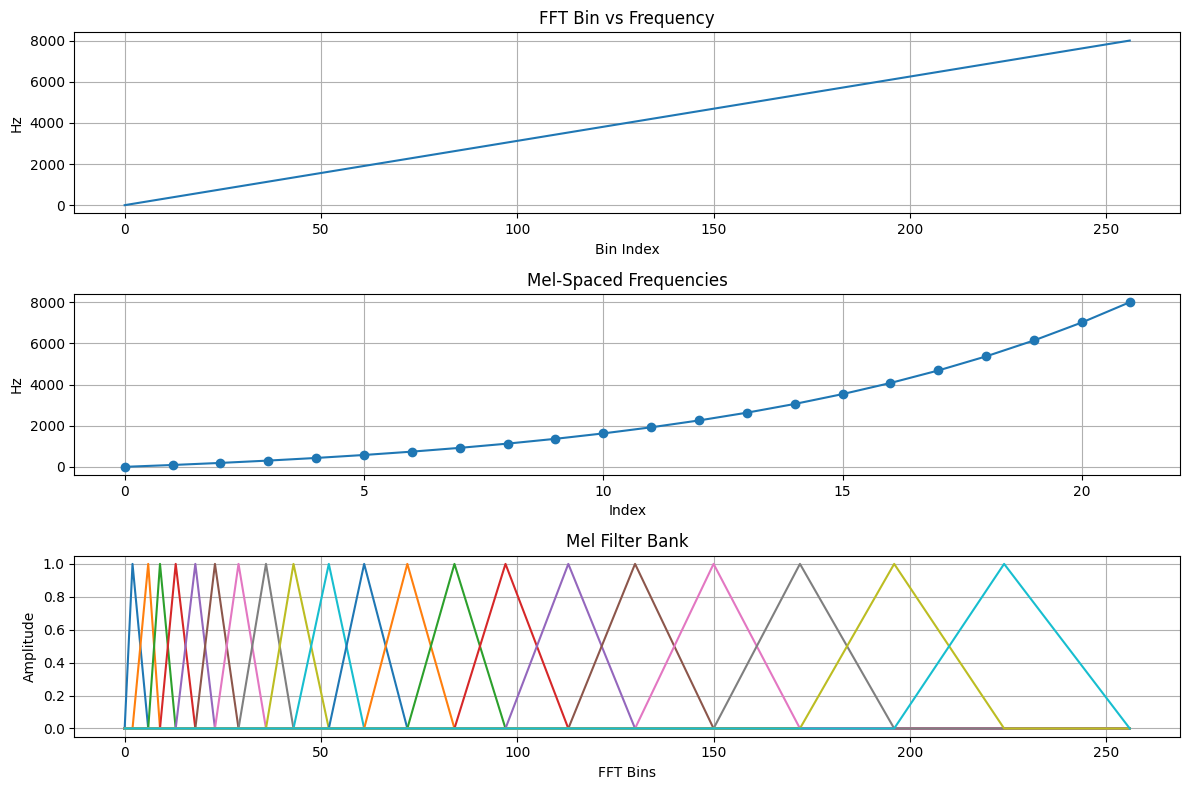


=== Experiment: fs=8000, N=256, M=10 ===
Filter 1: a=0, b=4, c=9
Filter 2: a=4, b=9, c=15
Filter 3: a=9, b=15, c=22
Filter 4: a=15, b=22, c=30
Filter 5: a=22, b=30, c=41
Filter 6: a=30, b=41, c=53
Filter 7: a=41, b=53, c=67
Filter 8: a=53, b=67, c=84
Filter 9: a=67, b=84, c=104
Filter 10: a=84, b=104, c=128


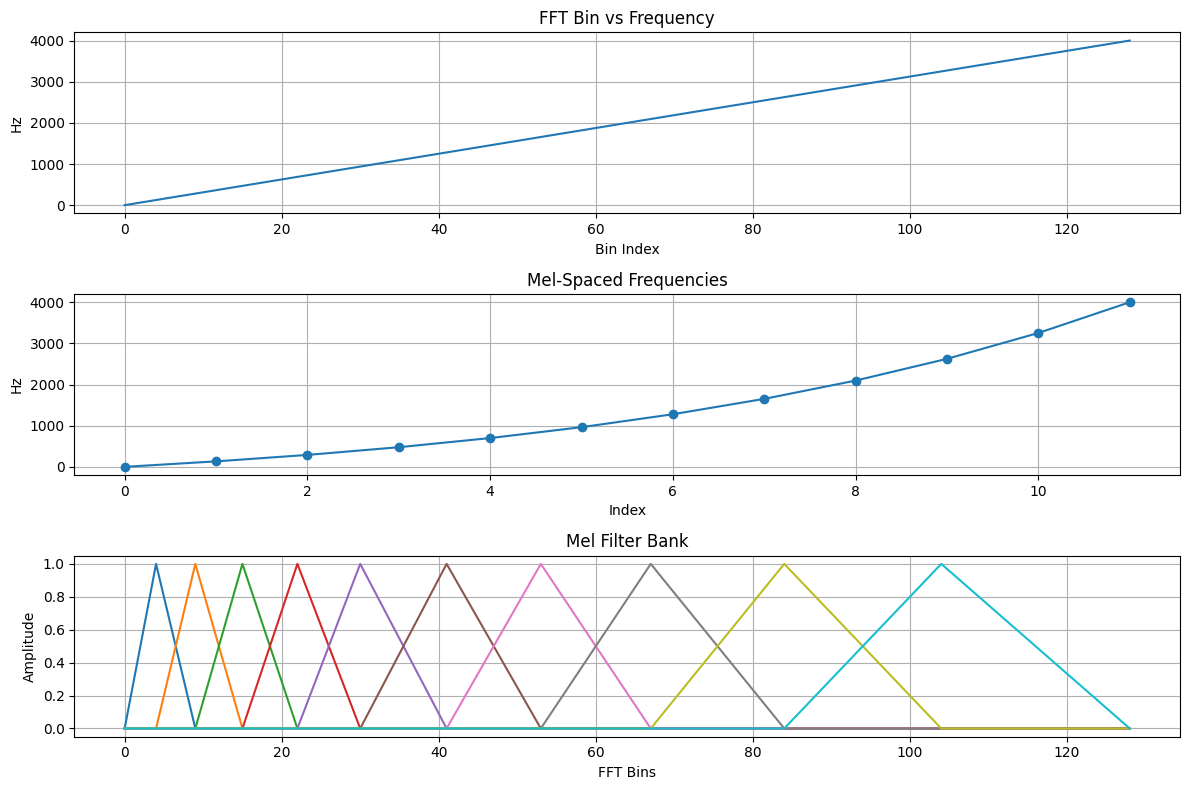


=== Experiment: fs=16000, N=1024, M=40 ===
Filter 1: a=0, b=2, c=5
Filter 2: a=2, b=5, c=9
Filter 3: a=5, b=9, c=12
Filter 4: a=9, b=12, c=16
Filter 5: a=12, b=16, c=19
Filter 6: a=16, b=19, c=24
Filter 7: a=19, b=24, c=28
Filter 8: a=24, b=28, c=33
Filter 9: a=28, b=33, c=38
Filter 10: a=33, b=38, c=43
Filter 11: a=38, b=43, c=48
Filter 12: a=43, b=48, c=54
Filter 13: a=48, b=54, c=61
Filter 14: a=54, b=61, c=67
Filter 15: a=61, b=67, c=75
Filter 16: a=67, b=75, c=82
Filter 17: a=75, b=82, c=90
Filter 18: a=82, b=90, c=99
Filter 19: a=90, b=99, c=108
Filter 20: a=99, b=108, c=118
Filter 21: a=108, b=118, c=128
Filter 22: a=118, b=128, c=139
Filter 23: a=128, b=139, c=151
Filter 24: a=139, b=151, c=163
Filter 25: a=151, b=163, c=176
Filter 26: a=163, b=176, c=190
Filter 27: a=176, b=190, c=205
Filter 28: a=190, b=205, c=221
Filter 29: a=205, b=221, c=238
Filter 30: a=221, b=238, c=256
Filter 31: a=238, b=256, c=275
Filter 32: a=256, b=275, c=296
Filter 33: a=275, b=296, c=317
Filter 3

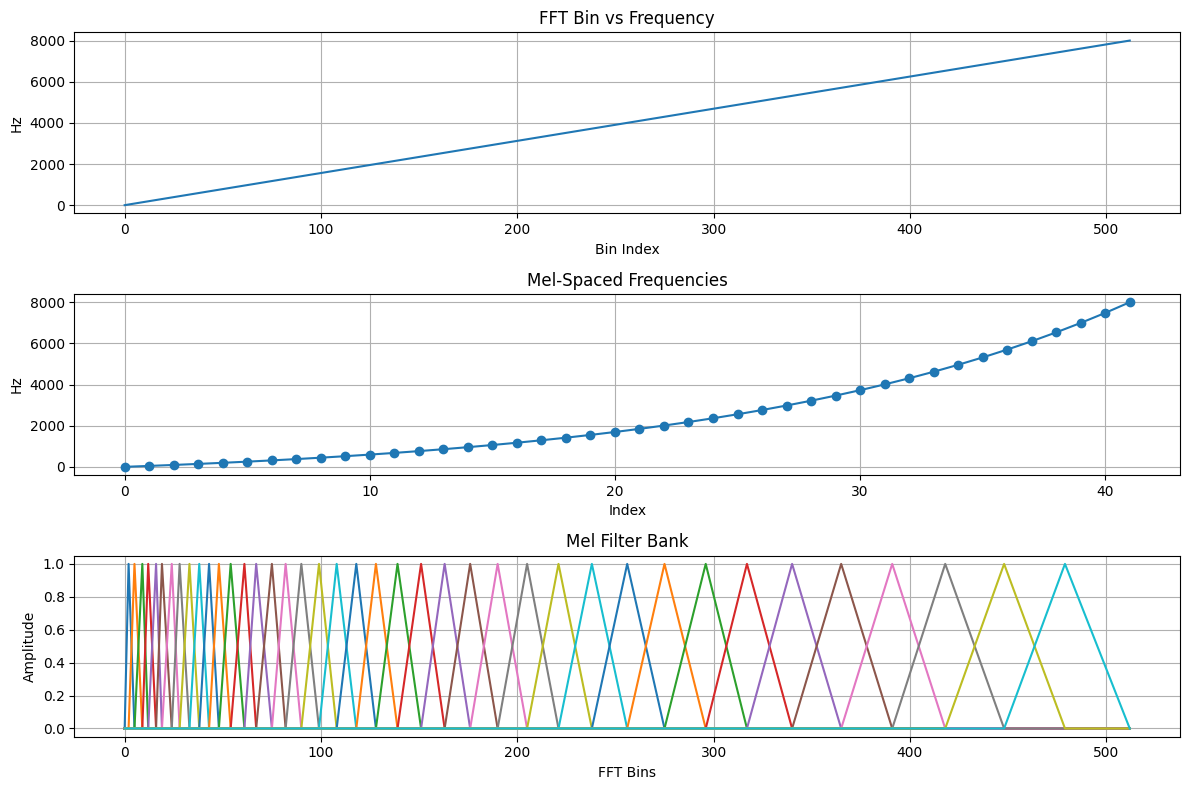

In [20]:
run_experiment(16000, 512, 20)
run_experiment(8000, 256, 10)
run_experiment(16000, 1024, 40)